<a href="https://colab.research.google.com/github/MoussaKIENDREBEOGO/text/blob/main/Copie_de_Intro_qiskit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

In [ ]:
!git clone https://gitlab.com/qworld/bronze-qiskit.git

fatal: destination path 'bronze-qiskit' already exists and is not an empty directory.


#Installation de Qiskit

In [ ]:
!pip install "qiskit[visualization]">=1.0
!pip install qiskit-aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.0 MB/s eta 0:00:00


In [ ]:
import qiskit
versions = qiskit.__version__
print("La version de Qiskit",versions)

La version de Qiskit 2.5.2


## Exemple de circuit avec Qiskit

1. Création


In [ ]:
# importer les objets de qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator
from random import randrange
from qiskit.quantum_info import Statevector

# Créer un circuit quantique et ces registres
qreg = QuantumRegister(2) # Registre quantique avec 2 qbits
creg = ClassicalRegister(2) # Registre classique avec 2 bits classique
circuit = QuantumCircuit(qreg,creg) # Circuit quantique composer de register quantique et de registre classique

# application d'une porte Hadamard au prémier qbit
circuit.h(qreg[0])
state_h = Statevector.from_instruction(circuit)
print(state_h)

# mettre le second qbit a l'etat |1>
circuit.x(qreg[1])
state_x = Statevector.from_instruction(circuit)
print(state_x)

# application de la porte CNOT(first_qubit,second_qubit)
circuit.cx(qreg[0],qreg[1])
state_cx = Statevector.from_instruction(circuit)
print(state_cx)

# messurer les deux qbits
circuit.measure(qreg,creg)

print("Circuit quantique crée :)")

Statevector([0.70710678+0.j, 0.70710678+0.j, 0.        +0.j,
             0.        +0.j],
            dims=(2, 2))
Statevector([0.        +0.j, 0.        +0.j, 0.70710678+0.j,
             0.70710678+0.j],
            dims=(2, 2))
Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
Circuit quantique crée :)


2. Dessinez le circuit

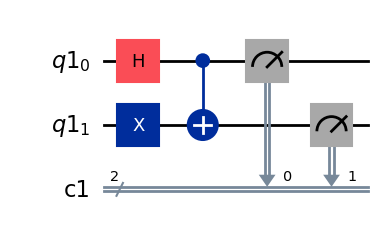

In [ ]:
circuit.draw(output='mpl')

3. Exécutez le circuit 1 024 fois dans le simulateur local et affichez les résultats observés.

In [ ]:
## execute the circuit 1024 times
job = AerSimulator().run(circuit,shots=1024)
# get the result
counts = job.result().get_counts(circuit)
print(counts)

{'01': 518, '10': 506}


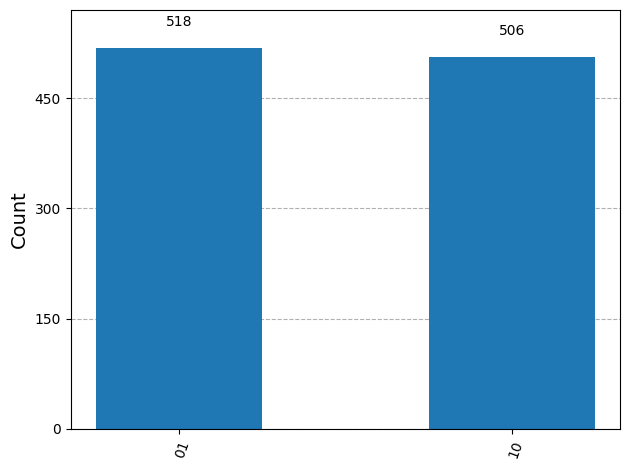

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

#Opérateur d'Hadamard

<h3> La première expérience</h3>

Notre bit quantique (<b>qubit</b>) se trouve initialement dans l'état 0, représenté par $ \ket{0} = \myvector{1 \\ 0} $.

<i>$ \ket{\cdot} $ est appelé « notation ket » : la notation ket est utilisée pour représenter un vecteur colonne en mécanique quantique.
Pour un vecteur colonne donné $ \ket{v} $, sa transposée conjuguée est un vecteur ligne représenté par $ \bra{v} $ (notation bra).
</i>

<h4> Le circuit à un seul Hadamard </h4>

Nous concevons un circuit à un qubit et effectuons une seule fois une expérience de « lancer de pièce quantique ».

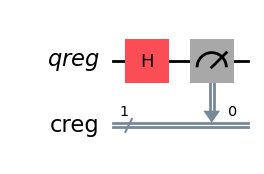

In [ ]:
# importation de tous les objets et méthodes nécessaires aux circuits quantiques
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator

# définition d'un registre quantique à un qubit
q = QuantumRegister(1, "qreg")

# définition d'un registre classique à un bit
# il stocke le résultat de la mesure de la partie quantique
c = ClassicalRegister(1, "creg")

# Définir notre circuit quantique
qc = QuantumCircuit(q, c)

# Appliquer la porte h (Hadamard : lancer de pièce quantique) au premier qubit
qc.h(q[0])

# Mesurer le premier qubit et stocker le résultat dans le premier bit classique
qc.measure(q, c)

# Dessiner le circuit à l'aide de matplotlib
qc.draw(output='mpl')

## Execution du circuite

{'0': 4990, '1': 5010}

L'état 0 est observé avec une fréquence de %  49.9
L'état 1 est observé avec une fréquence de %  50.1



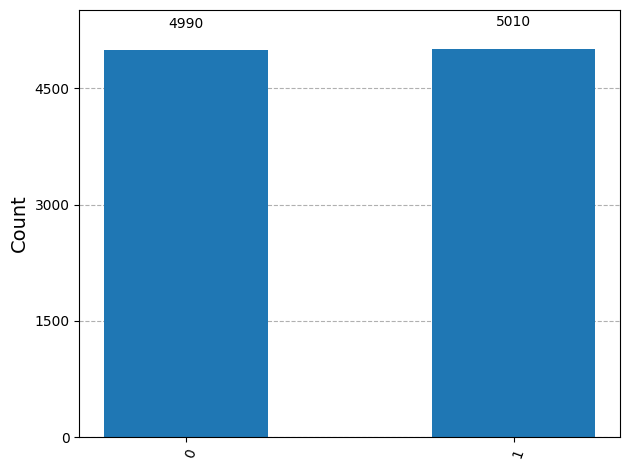

In [ ]:
# exécuter le circuit 10 000 fois dans le simulateur local

job = AerSimulator().run(qc, shots=10000)
counts = job.result().get_counts(qc)
print(counts) # afficher les résultats

print()
n_zeros = counts['0']
n_ones = counts['1']
print("L'état 0 est observé avec une fréquence de % ", 100 * n_zeros / (n_zeros + n_ones))
print("L'état 1 est observé avec une fréquence de % ", 100 * n_ones / (n_zeros + n_ones))

# on peut afficher le résultat à l'aide d'un histogramme
print()
from qiskit.visualization import plot_histogram
plot_histogram(counts)

<h4> Le circuit à deux Hadamards </h4>

Nous concevons un circuit comportant un qubit et appliquons deux fois l'opération de « lancer de pièce quantique ».

Vecteur détat 1: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
--- Vecteur d'état (Statevector) ---
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


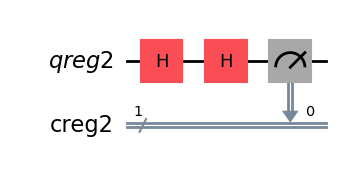

In [ ]:
# Importation de tous les objets et méthodes nécessaires aux circuits quantiques
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

# Définition d'un registre quantique à un qubit
q2 = QuantumRegister(1, 'qreg2')

# définir un registre classique à un bit
# il stocke le résultat de la mesure de la partie quantique
c2 = ClassicalRegister(1, 'creg2')

# définir notre circuit quantique
qc2 = QuantumCircuit(q2, c2)

# appliquer la porte h (Hadamard : lancer de pièce quantique) au premier qubit
qc2.h(q2[0])

#vecteur d'état
state1 = Statevector.from_instruction(qc2)
print("Vecteur détat 1:", state1)

# appliquer une porte h (Hadamard : lancer de pièce quantique) au premier qubit une nouvelle fois
qc2.h(q2[0])

# 2. On récupère le vecteur d'état directement depuis le circuit
state = Statevector.from_instruction(qc2)

# 3. Affichage des résultats
print("--- Vecteur d'état (Statevector) ---")
print(state)

# mesurer le premier qubit et stocker le résultat dans le premier bit classique
qc2.measure(q2, c2)

# dessiner le circuit à l'aide de matplotlib
qc2.draw(output='mpl') # relancer la cellule si la figure ne s'affiche pas

{'0': 10000}


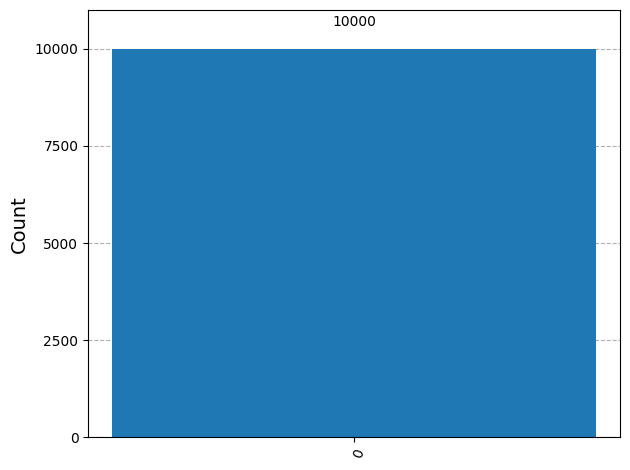

In [ ]:
job = AerSimulator().run(qc2,shots=10000)
counts2 = job.result().get_counts(qc2)
print(counts2)
plot_histogram(counts2)

#Un qubit
_Les systèmes quantiques sont des systèmes linéaires : « Les états quantiques sont représentés par des vecteurs et les opérateurs quantiques par des matrices. Les nouveaux états quantiques sont calculés à l'aide des multiplications matrice-vecteur correspondantes. »_

Un qubit (bit quantique) possède deux états : l'état 0 et l'état 1.

Ils sont notés selon la notation ket :

$ \ket{0} = \myvector{1 \\ 0} $ et $ \ket{1} = \myvector{0\\ 1} $.



<h3> Opérateur NOT </h3>

L'opérateur NOT inverse la valeur d'un qubit.

On utilise des lettres majuscules pour la forme matricielle des opérateurs :

$ X = \X$.

<br>
L'action de $ X $ sur le qubit :

$ X \ket{0} = \ket{1} $.

Plus précisément, $ X \ket{0} = \X \vzero = \vone = \ket{1} $.

De même, $ X \ket{1} = \ket{0} $.

Plus précisément, $ X \ket{1} = \X \vone = \vzero = \ket{0} $.

<h3> Opérateur de Hadamard</h3>

L'opérateur de Hadamard ($ H $ ou porte h) s'apparente à un lancer de pièce équitable.

$$
    H = \hadamard.
$$

Il existe toutefois certaines différences :
<ul>
    <li> nous avons un <u>élément négatif</u>, et</li>
    <li> au lieu de $ \frac{1}{2} $, nous avons <u>sa racine carrée</u> $ \mypar{ \frac{1}{\sqrt{2}} } $. </li>
</ul>


<h4> Hadamard en une étape</h4>

On part de $ \ket{0} $.

Après application de $ H $ :

$$
  H \ket{0} =  \hadamard \vzero =  \stateplus.
$$

Après la mesure, on observe les états $ \ket{0} $ et $ \ket{1} $ avec une probabilité égale de $ \frac{1}{2} $.

Comment cela est-il possible alors que leurs valeurs sont égales à $ \frac{1}{\sqrt{2}} $ ?

### États $ \ket{+} $ et $ \ket{-} $

Dans la littérature, les états quantiques obtenus après avoir appliqué $ H $ à $ \ket{0} $ et $ \ket{1} $ sont respectivement appelés états **ket-plus** ($\ket{+}$) et **ket-moins** ($ \ket{-} $) :

$ \ket{+} = H \ket{0} = \hadamard \vzero = \stateplus $

$ \ket{-} = H \ket{1} =  \hadamard \vone = \stateminus $


#Visualisation d'un qubit (à valeur réelle)
Supposons que nous ayons un seul qubit.

Chaque état quantique possible (à valeur réelle) de ce qubit correspond à un point dans un espace à deux dimensions.

Il peut également être représenté par un vecteur allant de l'origine à ce point.

Commençons par la représentation visuelle des états quantiques suivants :

$$ \ket{0} =  \myvector{1\\0}, ~~ \ket{1} = \myvector{0\\1} , ~~ -\ket{0} = \myrvector{-1\\0}, ~~\mbox{et}~~ -\ket{1} = \myrvector{0\\-1}. $$

Nous représentons ces états quantiques sous forme de points.

Nous utilisons l'une de nos fonctions prédéfinies pour tracer les axes : « draw_axes() ». Nous incluons nos fonctions prédéfinies à l'aide de la ligne de code suivante :

    %run quantum.py

In [ ]:
%%writefile quantum.py

import sys
sys.path.insert(0, '/content/bronze-qiskit/qworld/include/')

from drawing import draw_axes, draw_unit_circle, draw_quantum_state, draw_qubit, draw_qubit_grover, show_plt

from quantum_state import random_qstate_by_value, random_qstate_by_angle, angle_qstate

from grover import giant_oracle, giant_oracle2, giant_diffusion, Uf, Uf_8

Overwriting quantum.py


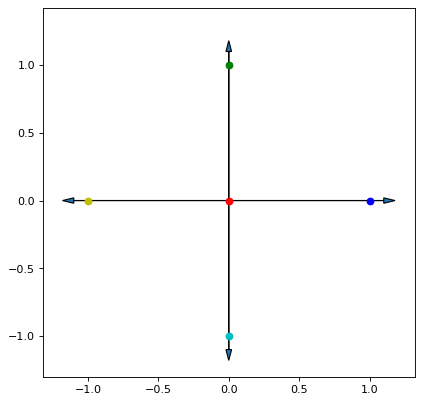

In [ ]:
# importation des méthodes de dessin
from matplotlib.pyplot import plot, figure, show

# tracé d'une figure
figure(figsize=(6,6), dpi=80)

# inclusion de nos fonctions prédéfinies
%run quantum.py

# tracé des axes
draw_axes()

# tracer l'origine
plot(0, 0, "ro") # un point de couleur rouge

# tracer ces états quantiques sous forme de points (de couleur bleue, verte, jaune et cyan)
plot(1, 0, "bo")
plot(0, 1, "go")
plot(-1, 0, "yo")
plot(0, -1, "co")

show()

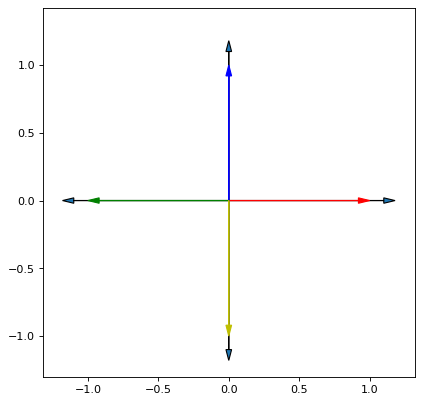

In [ ]:
# import the drawing methods
from matplotlib.pyplot import figure, arrow, show

# draw a figure
figure(figsize=(6,6), dpi=80)

# include our predefined functions
%run quantum.py

# draw the axes
draw_axes()

# draw the quantum states as vectors (in red, blue, green, and yellow colors)
arrow(0,0,0.92,0,head_width=0.04, head_length=0.08, color="r")
arrow(0,0,0,0.92,head_width=0.04, head_length=0.08, color="b")
arrow(0,0,-0.92,0,head_width=0.04, head_length=0.08, color="g")
arrow(0,0,0,-0.92,head_width=0.04, head_length=0.08, color="y")

show()

<font style="font-size:28px;" align="left"><b>Deux qubits</b></font>
<br>
Rappelons que lorsqu’on a un système quantique à deux qubits, on peut représenter ses états par $ \ket{00}, \ket{01}, \ket{10}, \ket{11} $.

L’état $ \ket{ab} $ signifie que
<ul>
    <li>le premier qubit est dans l’état $ \ket{a} $ et </li>
    <li> le deuxième qubit est dans l'état $ \ket{b} $, </li>
</ul>
où $ a, b \in \{0, 1\} $.

$ \ket{ab} = \ket{a} \otimes \ket{b} $ (ou, en abrégé, $\ket{a}\ket{b}$.

<h3> Exercice (représentation vectorielle)</h3>

Vérifiez les représentations vectorielles de $ \ket{00}, \ket{01}, \ket{10}, \ket{11} $ :

$$
    \ket{00} = \myvector{1 \\ 0 \\ 0 \\ 0},
    ~~~~~~
    \ket{01} = \myvector{0 \\ 1 \\ 0 \\ 0},
    ~~~~~~
    \ket{10} = \myvector{0 \\ 0 \\ 1 \\ 0},
    ~~~ \mbox{ et }  ~~~
    \ket{11} = \myvector{0 \\ 0 \\ 0 \\ 1}.
$$

<h3>Opérateurs sur deux qubits</h3>

Nous définissons un circuit quantique à deux qubits et appliquons l'opérateur de Hadamard à chacun d'entre eux.

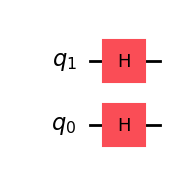

In [ ]:
from qiskit import QuantumCircuit

# Notez la représentation concise d'un circuit quantique
qc = QuantumCircuit(2)

qc.h(0)
qc.h(1)

qc.draw(output="mpl", reverse_bits=True)

Ces deux opérateurs de Hadamard peuvent également être représentés sous la forme d'un seul opérateur quantique agissant sur deux qubits : $ H \otimes H $.

$$
   H^{\otimes 2} = H \otimes H = \hadamard \otimes \hadamard = \Htwo .
$$

In [ ]:
from qiskit_aer import UnitarySimulator

job = UnitarySimulator().run(qc)
current_unitary = job.result().get_unitary(qc, decimals=3).data
for row in current_unitary:
    column = ""
    for entry in row:
        column = column + str(entry.real) + " "
    print(column)

0.5 0.5 0.5 0.5 
0.5 -0.5 0.5 -0.5 
0.5 0.5 -0.5 -0.5 
0.5 -0.5 -0.5 0.5 


<h3> Opérateur CNOT </h3>


CNOT est un opérateur défini sur deux qubits :

$$
    CNOT = \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} .
$$

Son effet est très simple : si l'état du premier qubit est égal à un, alors l'état du deuxième qubit est inversé.

Si l'état du premier qubit est égal à zéro, alors l'état du deuxième qubit reste inchangé.

En résumé :
<ul>
    <li>$ CNOT \ket{00} = \ket{00} $, </li>
    <li>$ CNOT \ket{01} = \ket{01} $, </li>
    <li>$ CNOT \ket{10} = \ket{11} $, et, </li>
    <li>$ CNOT \ket{11} = \ket{10} $. </li>
</ul>

CNOT signifie « Controlled-NOT » : l’opérateur NOT est appliqué de manière contrôlée.

<h3> cx-gate </h3>

Dans Qiskit, l'opérateur CNOT est représenté par cx-gate.

Il prend deux arguments : le qubit contrôleur et le qubit cible.

Son implémentation est la suivante :

<i> <b>x-gate</b> (opérateur NOT) est appliqué au <u>qubit cible</u> qui est <b>CONTRÔLÉ</b> par <u>le qubit contrôleur</u>.</i>

Nous appliquons l’opérateur CNOT aux états $ \ket{00}, \ket{01}, \ket{10}, \ket{11} $, puis nous mesurons chacun d’entre eux.

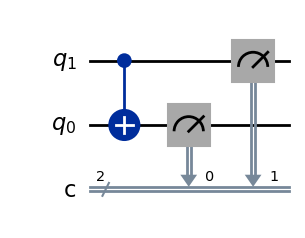

00 --CNOT->  {'00': 1024}


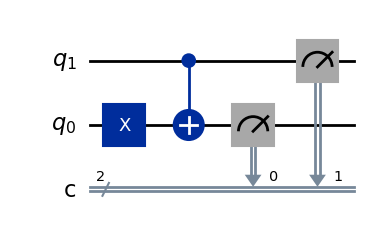

01 --CNOT->  {'01': 1024}


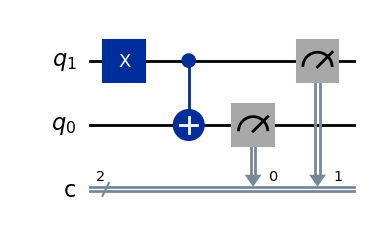

10 --CNOT->  {'11': 1024}


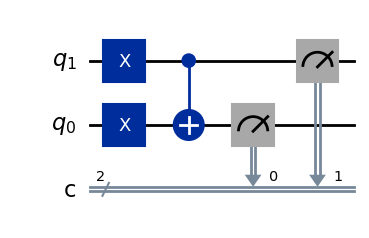

11 --CNOT->  {'10': 1024}


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

pairs = ["00","01","10","11"]

for pair in pairs:
    qc = QuantumCircuit(2,2)
    # initialisation de la paire
    # nous suivons l'ordre de lecture de Qiskit
    # q1-tensor-q0
    if pair[1] == "1" :
        qc.x(0)
    if pair[0] == "1" :
        qc.x(1)
    qc.cx(1, 0)
    qc.measure(0, 0)
    qc.measure(1, 1)
    display(qc.draw(output="mpl", reverse_bits=True))
    job = AerSimulator().run(qc, shots=1024)
    counts = job.result().get_counts(qc)
    print(pair, "--CNOT-> ", counts)

In [ ]:
# !pip install qiskit-algorithms
# !pip install qiskit_optimization

##Objectif du problème : Le Max-Cut (Coupe Maximale)

Le but est de séparer un réseau de 7 nœuds (personnes) en deux groupes (A et B). Pour maximiser la diversité ou séparer des incompatibilités, nous voulons que le maximum d'arêtes (liens) reliant les nœuds se retrouvent entre les deux groupes, et non à l'intérieur d'un même groupe. Une arête est dite "coupée" si ses deux extrémités appartiennent à des groupes différents.Chaque nœud sera représenté par un qubit :
* Un qubit mesuré à 0 signifie que le nœud va dans le Groupe A.
* Un qubit mesuré à 1 signifie que le nœud va dans le Groupe B.

Le graphe possède 7 nœuds et 10 arêtes.


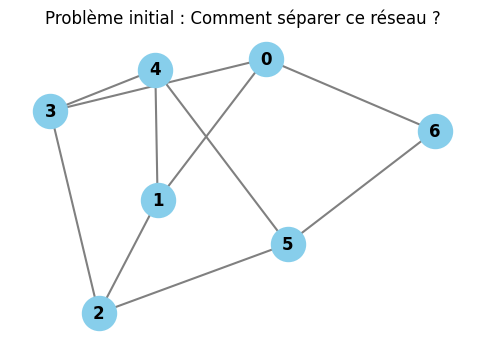

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Définition du graphe à 7 nœuds
graph = nx.Graph()
# Boucle externe
graph.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 0)])
# Arêtes internes complexes
graph.add_edges_from([(0, 3), (1, 4), (2, 5)])

print(f"Le graphe possède {graph.number_of_nodes()} nœuds et {graph.number_of_edges()} arêtes.")

# 2. Positionnement fixe des nœuds (pour que les deux figures soient identiques)
pos = nx.spring_layout(graph, seed=42)

# 3. Dessiner le graphe initial (tous les nœuds en bleu ciel)
plt.figure(figsize=(6, 4))
nx.draw_networkx_nodes(graph, pos, node_color='skyblue', node_size=600)
nx.draw_networkx_edges(graph, pos, edge_color='gray', width=1.5)
nx.draw_networkx_labels(graph, pos, font_size=12, font_weight='bold')

plt.title("Problème initial : Comment séparer ce réseau ?")
plt.axis('off')
plt.show()

--- Structure du circuit construit ---


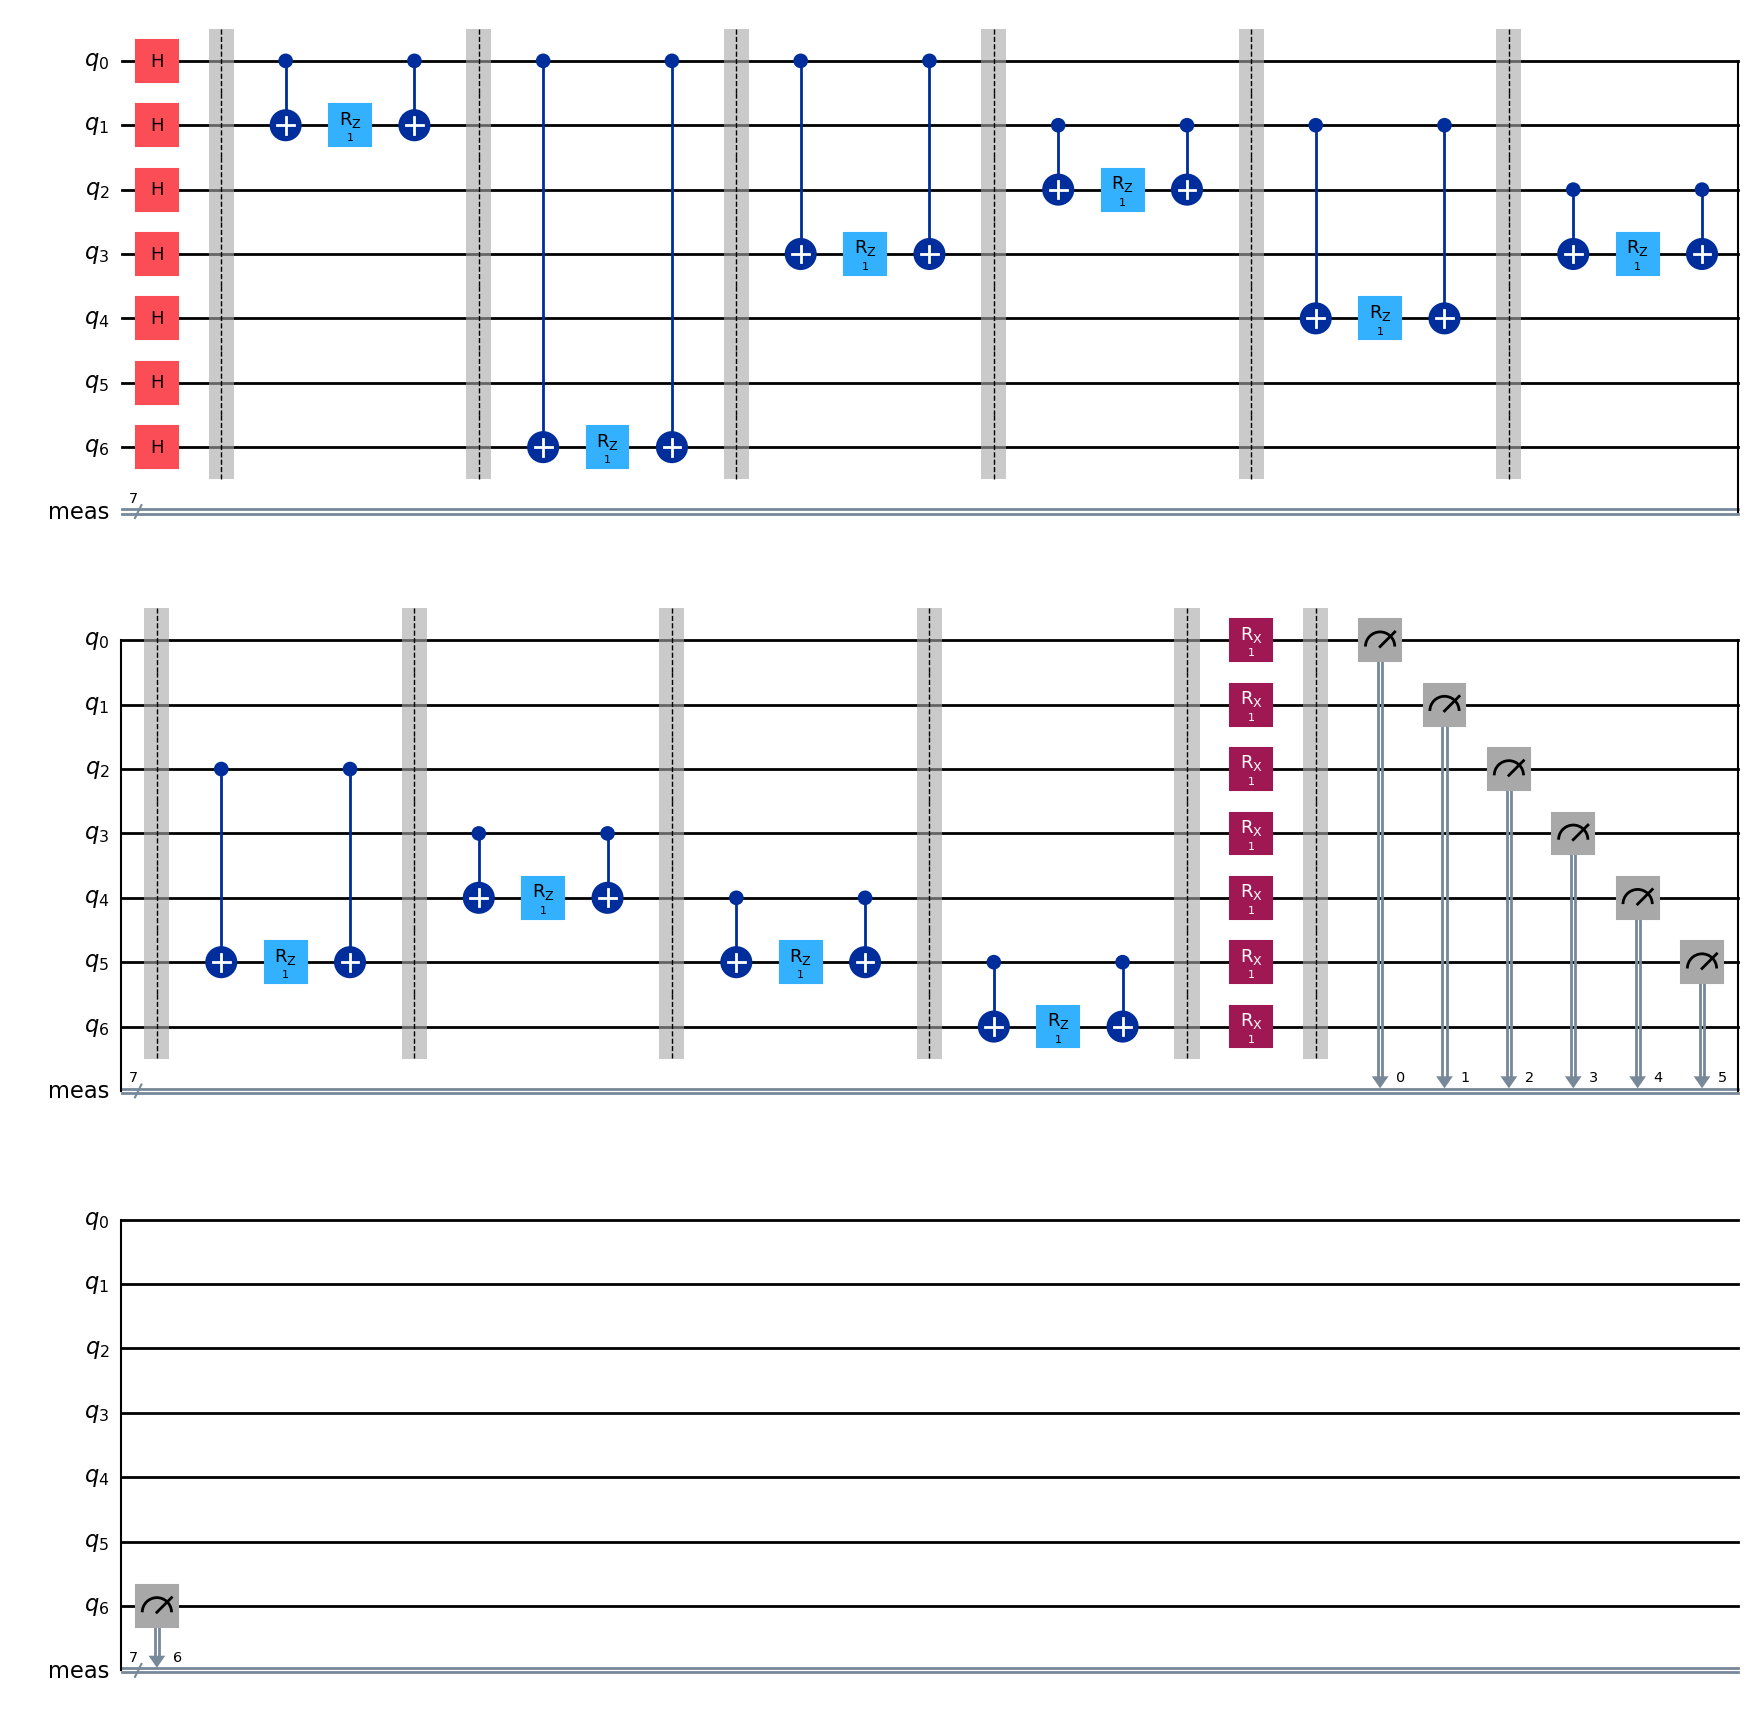

In [ ]:

# =====================================================================
# ÉTAPE 2 : Construction du Circuit Quantique avec les Portes de Base
# =====================================================================
# Fixons des angles arbitraires (gamma et beta) pour la démonstration pédagogique
gamma = 1.0  # Angle pour les arêtes
beta = 0.5   # Angle pour le mélangeur

num_qubits = graph.number_of_nodes()
qc = QuantumCircuit(num_qubits)

# 1. Superposition initiale : Porte H sur tous les qubits
for i in range(num_qubits):
    qc.h(i)

qc.barrier()  # Pour séparer visuellement les étapes

# 2. Couche de Coût (Arêtes) : Traduction de chaque connexion du graphe
for u, v in graph.edges():
    # Une interaction Ising ZZ se fait avec : CNOT -> RZ -> CNOT
    qc.cx(u, v)
    qc.rz(gamma, v)
    qc.cx(u, v)
    qc.barrier()

# 3. Couche de Mélange : Porte RX sur tous les qubits
for i in range(num_qubits):
    qc.rx(2 * beta, i)

# 4. Mesure finale de tous les qubits
qc.measure_all()

print("--- Structure du circuit construit ---")
qc.draw(output='mpl')




--- Résultat Quantique ---
Meilleure chaîne mesurée (format Qiskit q6...q0) : 0101010
Nombre d'arêtes coupées : 9 sur 10


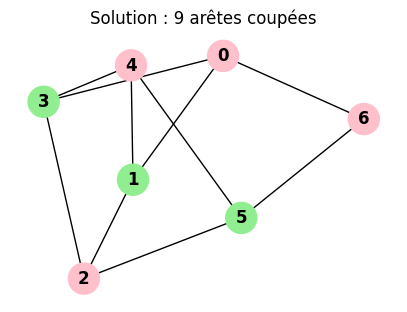

In [ ]:
# =====================================================================
# ÉTAPE 3 : Exécution et Recherche du meilleur résultat
# =====================================================================
sampler = StatevectorSampler()
job = sampler.run([qc], shots=1000)
result = job.result()[0]

# Extraction des mesures (dictionnaire des chaînes de bits)
counts = result.data.meas.get_counts()

# Fonction classique pour compter le nombre d'arêtes coupées par une solution
def evaluer_coupe(chaine_bits, graphe):
    # Attention au sens de lecture de Qiskit : le qubit 0 est tout à droite !
    # On inverse la chaîne pour que l'indice corresponde au numéro du nœud
    bits = [int(b) for b in reversed(chaine_bits)]
    coupe = 0
    for u, v in graphe.edges():
        if bits[u] != bits[v]:  # Si les deux nœuds sont dans des groupes différents
            coupe += 1
    return coupe

# Recherche de la chaîne de bits qui coupe le plus d'arêtes
meilleure_solution = max(counts.keys(), key=lambda cb: evaluer_coupe(cb, graph))
max_aretes_coupees = evaluer_coupe(meilleure_solution, graph)

# Convertir la chaîne de bits en liste de groupes pour l'affichage (0 ou 1)
# On ré-inverse pour associer correctement l'index au nœud
solution_liste = [int(b) for b in reversed(meilleure_solution)]

print("\n--- Résultat Quantique ---")
print(f"Meilleure chaîne mesurée (format Qiskit q6...q0) : {meilleure_solution}")
print(f"Nombre d'arêtes coupées : {max_aretes_coupees} sur {graph.number_of_edges()}")

# =====================================================================
# ÉTAPE 4 : Affichage de la Solution
# =====================================================================
colors = ['pink' if g == 0 else 'lightgreen' for g in solution_liste]
plt.figure(figsize=(5, 3.5))
nx.draw_networkx(graph, pos, node_color=colors, node_size=500, font_weight='bold')
plt.title(f"Solution : {max_aretes_coupees} arêtes coupées")
plt.axis('off')
plt.show()
